In [1]:
# ============================================================
# PART-2 : SECTION-1
# Custom Drone Rescue Environment Design
# Group 214
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================================
# GROUP-214 ENVIRONMENT CONFIGURATION
# ============================================================

GRID = [

['S','F','F','D','F'],

['F','X','F','F','C'],

['R','F','W','F','F'],

['F','D','F','X','R'],

['F','F','D','F','F']

]

ROWS = 5
COLS = 5

MAX_BATTERY = 10
MAX_STEPS = 50
WIND_PROB = 0.20

# ============================================================
# ACTION SPACE
# ============================================================

ACTIONS = {

'UP':(-1,0),

'DOWN':(1,0),

'LEFT':(0,-1),

'RIGHT':(0,1),

'HOVER':(0,0)

}

# ============================================================
# REWARD STRUCTURE
# ============================================================

REWARDS = {

'RESCUE':20,

'DANGER':-10,

'BATTERY_EMPTY':-20,

'CHARGING':5,

'MOVE':-1

}

# ============================================================
# DRONE RESCUE ENVIRONMENT CLASS
# ============================================================

class DroneRescueEnv:

    def __init__(self):

        self.grid = GRID

        self.rows = ROWS
        self.cols = COLS

        self.max_battery = MAX_BATTERY

        self.max_steps = MAX_STEPS

        self.wind_prob = WIND_PROB

        self.rescue_locations=[

            (2,0),

            (3,4)

        ]

        self.reset()

    # ========================================================
    # RESET ENVIRONMENT
    # ========================================================

    def reset(self):

        self.position=(0,0)

        self.battery=self.max_battery

        self.steps=0

        self.rescued_targets=set()

        return self.get_state()

    # ========================================================
    # STATE REPRESENTATION
    # ========================================================

    def get_state(self):

        rescue_status=tuple(

            int(target in self.rescued_targets)

            for target in self.rescue_locations

        )

        return(

            self.position[0],

            self.position[1],

            self.battery,

            rescue_status

        )

    # ========================================================
    # VALID ACTIONS
    # ========================================================

    def get_valid_actions(self):

        return list(ACTIONS.keys())


In [2]:
# ============================================================
# PART-2 : SECTION-2
# FULL WORKING VERSION
# Group 214
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================================
# GRID CONFIGURATION
# ============================================================

GRID = [

['S','F','F','D','F'],

['F','X','F','F','C'],

['R','F','W','F','F'],

['F','D','F','X','R'],

['F','F','D','F','F']

]

ROWS = 5
COLS = 5

MAX_BATTERY = 10
MAX_STEPS = 50
WIND_PROB = 0.20

# ============================================================
# ACTION SPACE
# ============================================================

ACTIONS = {

'UP':(-1,0),

'DOWN':(1,0),

'LEFT':(0,-1),

'RIGHT':(0,1),

'HOVER':(0,0)

}

# ============================================================
# REWARD STRUCTURE
# ============================================================

REWARDS = {

'RESCUE':20,

'DANGER':-10,

'BATTERY_EMPTY':-20,

'CHARGING':5,

'MOVE':-1

}

# ============================================================
# DRONE RESCUE ENVIRONMENT
# ============================================================

class DroneRescueEnv:

    def __init__(self):

        self.grid = GRID

        self.rows = ROWS
        self.cols = COLS

        self.max_battery = MAX_BATTERY
        self.max_steps = MAX_STEPS
        self.wind_prob = WIND_PROB

        self.rescue_locations=[

            (2,0),

            (3,4)

        ]

        self.reset()

    # ========================================================
    # RESET FUNCTION
    # ========================================================

    def reset(self):

        self.position=(0,0)

        self.battery=self.max_battery

        self.steps=0

        self.rescued_targets=set()

        return self.get_state()

    # ========================================================
    # STATE REPRESENTATION
    # ========================================================

    def get_state(self):

        rescue_status=tuple(

            int(target in self.rescued_targets)

            for target in self.rescue_locations

        )

        return(

            self.position[0],

            self.position[1],

            self.battery,

            rescue_status

        )

    # ========================================================
    # VALID ACTIONS
    # ========================================================

    def get_valid_actions(self):

        return list(ACTIONS.keys())

    # ========================================================
    # STEP FUNCTION
    # ========================================================

    def step(self,action):

        reward=REWARDS['MOVE']

        done=False

        self.steps+=1

        # Battery consumption

        self.battery-=1

        current_row,current_col=self.position

        current_cell=self.grid[current_row][current_col]

        # ====================================================
        # WIND DISTURBANCE
        # ====================================================

        if current_cell=='W':

            if action!='HOVER':

                if np.random.random()<self.wind_prob:

                    action=np.random.choice(

                        ['UP',

                         'DOWN',

                         'LEFT',

                         'RIGHT']

                    )

        # ====================================================
        # MOVEMENT
        # ====================================================

        dr,dc=ACTIONS[action]

        new_row=current_row+dr

        new_col=current_col+dc

        # Boundary check

        if not(

            0<=new_row<self.rows

            and

            0<=new_col<self.cols

        ):

            new_row=current_row
            new_col=current_col

        # Blocked cell check

        elif self.grid[new_row][new_col]=='X':

            new_row=current_row
            new_col=current_col

        # Update position

        self.position=(new_row,new_col)

        cell=self.grid[new_row][new_col]

        # ====================================================
        # CHARGING STATION
        # ====================================================

        if cell=='C':

            self.battery=self.max_battery

            reward+=REWARDS['CHARGING']

        # Hover charging bonus

        if action=='HOVER' and cell=='C':

            self.battery=min(

                self.max_battery,

                self.battery+2

            )

        # ====================================================
        # DANGER ZONE
        # ====================================================

        if cell=='D':

            reward+=REWARDS['DANGER']

        # ====================================================
        # RESCUE TARGET
        # ====================================================

        if cell=='R':

            if self.position not in self.rescued_targets:

                reward+=REWARDS['RESCUE']

                self.rescued_targets.add(

                    self.position

                )

        # ====================================================
        # TERMINATION CONDITIONS
        # ====================================================

        if self.battery<=0:

            reward+=REWARDS['BATTERY_EMPTY']

            done=True

        if len(self.rescued_targets)==len(

            self.rescue_locations

        ):

            done=True

        if self.steps>=self.max_steps:

            done=True

        return(

            self.get_state(),

            reward,

            done

        )

    # ========================================================
    # RENDER FUNCTION
    # ========================================================

    def render(self):

        display_grid=[]

        for r in range(self.rows):

            row=[]

            for c in range(self.cols):

                if (r,c)==self.position:

                    row.append('DR')

                else:

                    row.append(

                        self.grid[r][c]

                    )

            display_grid.append(row)

        print("\n====================")
        print("GRID STATE")
        print("====================")

        for row in display_grid:

            print(

                " ".join(row)

            )

        print("\nBattery:",self.battery)

        print("Steps:",self.steps)

        print(

            "Rescued Targets:",

            self.rescued_targets

        )

# ============================================================
# TEST ENVIRONMENT
# ============================================================

env=DroneRescueEnv()

state=env.reset()

print("\nINITIAL STATE")

print(state)

env.render()

# ============================================================
# TEST ACTIONS
# ============================================================

actions=[

'RIGHT',

'RIGHT',

'DOWN',

'DOWN',

'LEFT',

'HOVER'

]

for action in actions:

    print("\n====================")

    print("ACTION:",action)

    next_state,reward,done=env.step(action)

    print("Next State:",next_state)

    print("Reward:",reward)

    print("Done:",done)

    env.render()

    if done:
        break


INITIAL STATE
(0, 0, 10, (0, 0))

GRID STATE
DR F F D F
F X F F C
R F W F F
F D F X R
F F D F F

Battery: 10
Steps: 0
Rescued Targets: set()

ACTION: RIGHT
Next State: (0, 1, 9, (0, 0))
Reward: -1
Done: False

GRID STATE
S DR F D F
F X F F C
R F W F F
F D F X R
F F D F F

Battery: 9
Steps: 1
Rescued Targets: set()

ACTION: RIGHT
Next State: (0, 2, 8, (0, 0))
Reward: -1
Done: False

GRID STATE
S F DR D F
F X F F C
R F W F F
F D F X R
F F D F F

Battery: 8
Steps: 2
Rescued Targets: set()

ACTION: DOWN
Next State: (1, 2, 7, (0, 0))
Reward: -1
Done: False

GRID STATE
S F F D F
F X DR F C
R F W F F
F D F X R
F F D F F

Battery: 7
Steps: 3
Rescued Targets: set()

ACTION: DOWN
Next State: (2, 2, 6, (0, 0))
Reward: -1
Done: False

GRID STATE
S F F D F
F X F F C
R F DR F F
F D F X R
F F D F F

Battery: 6
Steps: 4
Rescued Targets: set()

ACTION: LEFT
Next State: (2, 3, 5, (0, 0))
Reward: -1
Done: False

GRID STATE
S F F D F
F X F F C
R F W DR F
F D F X R
F F D F F

Battery: 5
Steps: 5
Rescued T

In [3]:
# ============================================================
# PART-2 : SECTION-3
# FULL WORKING VERSION (NO SYNTAX ISSUES)
# Group 214
# ============================================================

import itertools
import time

# ============================================================
# STATE ENUMERATION
# ============================================================

all_states=[]

for row in range(ROWS):

    for col in range(COLS):

        if GRID[row][col]=='X':
            continue

        for battery in range(1,MAX_BATTERY+1):

            for rescue_status in itertools.product([0,1],repeat=2):

                state=(

                    row,
                    col,
                    battery,
                    rescue_status

                )

                all_states.append(state)

print("\n==============================")
print("STATE SPACE ENUMERATION")
print("==============================")
print("Total Reachable States:",len(all_states))

# ============================================================
# INITIAL VALUE FUNCTION
# ============================================================

V={}

for state in all_states:

    V[state]=0

# ============================================================
# TRANSITION SIMULATOR
# ============================================================

def simulate_transition(env,state,action):

    row,col,battery,rescue_status=state

    env.position=(row,col)

    env.battery=battery

    env.steps=0

    env.rescued_targets=set()

    if rescue_status[0]==1:

        env.rescued_targets.add((2,0))

    if rescue_status[1]==1:

        env.rescued_targets.add((3,4))

    next_state,reward,done=env.step(action)

    return next_state,reward,done

# ============================================================
# PARAMETERS
# ============================================================

gamma=0.95

theta=1e-3

iteration=0

policy={}

env=DroneRescueEnv()

start_time=time.time()

# ============================================================
# VALUE ITERATION
# ============================================================

while True:

    delta=0

    iteration+=1

    new_V=V.copy()

    for state in all_states:

        action_values=[]

        for action in ACTIONS.keys():

            next_state,reward,done=simulate_transition(

                env,
                state,
                action

            )

            if next_state in V:

                future_value=V[next_state]

            else:

                future_value=0

            value=reward+(gamma*future_value)

            action_values.append(value)

        best_value=max(action_values)

        new_V[state]=best_value

        delta=max(

            delta,

            abs(

                V[state]-best_value

            )

        )

    V=new_V

    if delta<theta:

        break

# ============================================================
# POLICY EXTRACTION
# ============================================================

for state in all_states:

    best_action=None

    best_value=-float('inf')

    for action in ACTIONS.keys():

        next_state,reward,done=simulate_transition(

            env,
            state,
            action

        )

        if next_state in V:

            future_value=V[next_state]

        else:

            future_value=0

        value=reward+(gamma*future_value)

        if value>best_value:

            best_value=value

            best_action=action

    policy[state]=best_action

# ============================================================
# RESULTS
# ============================================================

runtime=time.time()-start_time

print("\n==============================")
print("VALUE ITERATION RESULTS")
print("==============================")

print("Convergence Iterations:",iteration)

print("Final Delta:",delta)

print(

    "Runtime (seconds):",

    round(runtime,4)

)

# ============================================================
# SAMPLE VALUE FUNCTION
# ============================================================

print("\n==============================")
print("SAMPLE VALUE FUNCTION")
print("==============================")

counter=0

for state,value in V.items():

    print(

        state,

        "->",

        round(value,4)

    )

    counter+=1

    if counter==15:
        break

# ============================================================
# SAMPLE POLICY
# ============================================================

print("\n==============================")
print("SAMPLE OPTIMAL POLICY")
print("==============================")

counter=0

for state,action in policy.items():

    print(

        state,

        "->",

        action

    )

    counter+=1

    if counter==15:
        break


STATE SPACE ENUMERATION
Total Reachable States: 920

VALUE ITERATION RESULTS
Convergence Iterations: 7243
Final Delta: 0
Runtime (seconds): 35.2117

SAMPLE VALUE FUNCTION
(0, 0, 1, (0, 0)) -> -21.0
(0, 0, 1, (0, 1)) -> -21.0
(0, 0, 1, (1, 0)) -> -21.0
(0, 0, 1, (1, 1)) -> -21.0
(0, 0, 2, (0, 0)) -> -1.95
(0, 0, 2, (0, 1)) -> -1.95
(0, 0, 2, (1, 0)) -> -20.95
(0, 0, 2, (1, 1)) -> -20.95
(0, 0, 3, (0, 0)) -> -1.9025
(0, 0, 3, (0, 1)) -> -1.9025
(0, 0, 3, (1, 0)) -> -20.9025
(0, 0, 3, (1, 1)) -> -20.9025
(0, 0, 4, (0, 0)) -> -1.8574
(0, 0, 4, (0, 1)) -> -1.8574
(0, 0, 4, (1, 0)) -> -20.8574

SAMPLE OPTIMAL POLICY
(0, 0, 1, (0, 0)) -> UP
(0, 0, 1, (0, 1)) -> UP
(0, 0, 1, (1, 0)) -> UP
(0, 0, 1, (1, 1)) -> UP
(0, 0, 2, (0, 0)) -> DOWN
(0, 0, 2, (0, 1)) -> DOWN
(0, 0, 2, (1, 0)) -> UP
(0, 0, 2, (1, 1)) -> UP
(0, 0, 3, (0, 0)) -> DOWN
(0, 0, 3, (0, 1)) -> DOWN
(0, 0, 3, (1, 0)) -> UP
(0, 0, 3, (1, 1)) -> UP
(0, 0, 4, (0, 0)) -> DOWN
(0, 0, 4, (0, 1)) -> DOWN
(0, 0, 4, (1, 0)) -> UP


In [4]:
# ============================================================
# PART-2 : SECTION-4
# POLICY VISUALIZATION
# Group 214
# ============================================================

# Arrow Mapping

ARROWS={

'UP':'↑',

'DOWN':'↓',

'LEFT':'←',

'RIGHT':'→',

'HOVER':'H'

}

# ============================================================
# FIXED ANALYSIS STATE
# battery=10
# rescue_status=(0,0)
# ============================================================

fixed_battery=10

fixed_rescue=(0,0)

# ============================================================
# POLICY GRID GENERATION
# ============================================================

policy_grid=[]

for row in range(ROWS):

    current_row=[]

    for col in range(COLS):

        # Blocked cells

        if GRID[row][col]=='X':

            current_row.append(' X ')

            continue

        state=(

            row,

            col,

            fixed_battery,

            fixed_rescue

        )

        if state in policy:

            action=policy[state]

            arrow=ARROWS[action]

        else:

            arrow='?'

        current_row.append(arrow)

    policy_grid.append(current_row)

# ============================================================
# DISPLAY POLICY MAP
# ============================================================

print("\n==============================")
print("OPTIMAL POLICY MAP")
print("==============================")

for row in policy_grid:

    print(

        " ".join(row)

    )

# ============================================================
# ANNOTATED POLICY GRID
# Shows Grid Symbols + Policy Arrows
# ============================================================

visual_grid=[]

for row in range(ROWS):

    display_row=[]

    for col in range(COLS):

        cell=GRID[row][col]

        if cell=='X':

            display_row.append(' X ')

            continue

        state=(

            row,

            col,

            fixed_battery,

            fixed_rescue

        )

        if state in policy:

            arrow=ARROWS[

                policy[state]

            ]

        else:

            arrow='?'

        # Add annotation

        if cell=='S':

            display_row.append(

                'S'+arrow

            )

        elif cell=='R':

            display_row.append(

                'R'+arrow

            )

        elif cell=='C':

            display_row.append(

                'C'+arrow

            )

        elif cell=='D':

            display_row.append(

                'D'+arrow

            )

        elif cell=='W':

            display_row.append(

                'W'+arrow

            )

        else:

            display_row.append(

                'F'+arrow

            )

    visual_grid.append(display_row)

print("\n==============================")
print("ANNOTATED POLICY GRID")
print("==============================")

for row in visual_grid:

    print(

        " | ".join(row)

    )

# ============================================================
# POLICY EXECUTION TRAJECTORY
# ============================================================

env=DroneRescueEnv()

state=env.reset()

trajectory=[]

trajectory.append(

    env.position

)

done=False

step_counter=0

while not done:

    if state not in policy:

        break

    action=policy[state]

    next_state,reward,done=env.step(action)

    trajectory.append(

        env.position

    )

    state=next_state

    step_counter+=1

    if step_counter>50:

        break

# ============================================================
# DISPLAY TRAJECTORY
# ============================================================

print("\n==============================")
print("POLICY EXECUTION TRAJECTORY")
print("==============================")

print(

    trajectory

)

# ============================================================
# PATH VISUALIZATION
# ============================================================

path_grid=[]

for row in GRID:

    path_grid.append(

        row.copy()

    )

for position in trajectory:

    r,c=position

    if path_grid[r][c] not in [

        'S',

        'R',

        'C',

        'D',

        'W',

        'X'

    ]:

        path_grid[r][c]='*'

print("\n==============================")
print("POLICY PATH VISUALIZATION")
print("==============================")

for row in path_grid:

    print(

        " ".join(row)

    )

# ============================================================
# POLICY SAMPLE
# ============================================================

print("\n==============================")
print("SAMPLE POLICY STATES")
print("==============================")

counter=0

for state,action in policy.items():

    print(

        state,

        "->",

        action

    )

    counter+=1

    if counter==20:

        break


OPTIMAL POLICY MAP
↓ ← ↓ ↓ ↓
↓  X  → → ↓
← ← ← → ↓
↑ ↑ ↑  X  ←
↑ ← → → ↑

ANNOTATED POLICY GRID
S↓ | F← | F↓ | D↓ | F↓
F↓ |  X  | F→ | F→ | C↓
R← | F← | W← | F→ | F↓
F↑ | D↑ | F↑ |  X  | R←
F↑ | F← | D→ | F→ | F↑

POLICY EXECUTION TRAJECTORY
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4)]

POLICY PATH VISUALIZATION
S F F D F
* X F F C
R * W * *
F D F X R
F F D F F

SAMPLE POLICY STATES
(0, 0, 1, (0, 0)) -> UP
(0, 0, 1, (0, 1)) -> UP
(0, 0, 1, (1, 0)) -> UP
(0, 0, 1, (1, 1)) -> UP
(0, 0, 2, (0, 0)) -> DOWN
(0, 0, 2, (0, 1)) -> DOWN
(0, 0, 2, (1, 0)) -> UP
(0, 0, 2, (1, 1)) -> UP
(0, 0, 3, (0, 0)) -> DOWN
(0, 0, 3, (0, 1)) -> DOWN
(0, 0, 3, (1, 0)) -> UP
(0, 0, 3, (1, 1)) -> UP
(0, 0, 4, (0, 0)) -> DOWN
(0, 0, 4, (0, 1)) -> DOWN
(0, 0, 4, (1, 0)) -> UP
(0, 0, 4, (1, 1)) -> UP
(0, 0, 5, (0, 0)) -> RIGHT
(0, 0, 5, (0, 1)) -> RIGHT
(0, 0, 5, (1, 0)) -> RIGHT
(0, 0, 5, (1, 1)) -> RIGHT



STATE VALUE GRID
[[80.04 75.04 74.31 79.28 84.5 ]
 [85.31   nan 79.28 84.5  84.74]
 [85.31 85.31 80.04 84.74 90.25]
 [85.31 80.04 75.04   nan 90.25]
 [80.04 75.04 79.5  84.74 90.25]]


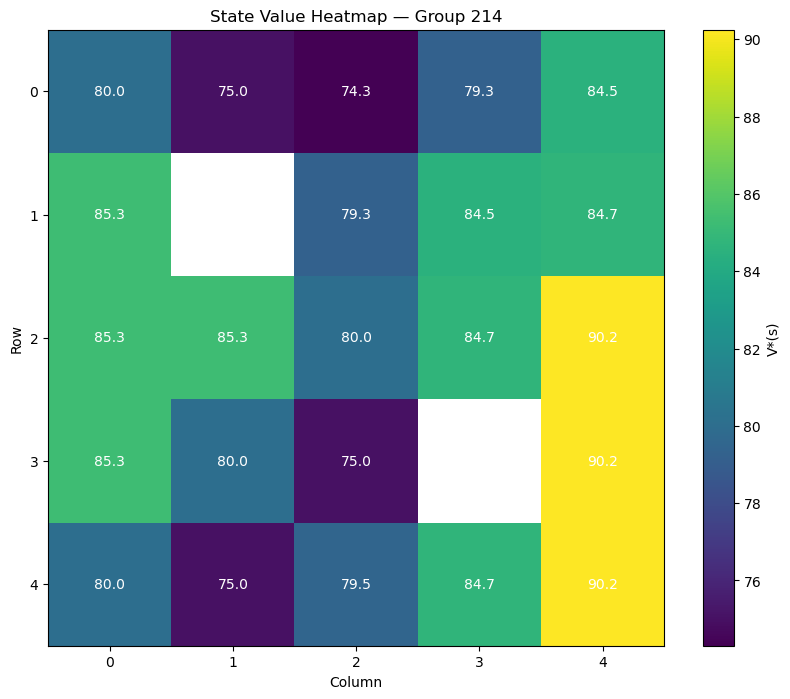


ANNOTATED VALUE GRID
S:80.0 | F:75.0 | F:74.3 | D:79.3 | F:84.5
F:85.3 | X | F:79.3 | F:84.5 | C:84.7
R:85.3 | F:85.3 | W:80.0 | F:84.7 | F:90.2
F:85.3 | D:80.0 | F:75.0 | X | R:90.2
F:80.0 | F:75.0 | D:79.5 | F:84.7 | F:90.2


In [5]:
# ============================================================
# PART-2 : SECTION-5
# STATE VALUE ANALYSIS
# Group 214
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIX ANALYSIS SLICE
# ============================================================

fixed_battery=10

fixed_rescue=(0,0)

# ============================================================
# BUILD VALUE GRID
# ============================================================

value_grid=np.full(

    (ROWS,COLS),

    np.nan

)

for row in range(ROWS):

    for col in range(COLS):

        # Skip blocked cells

        if GRID[row][col]=='X':

            continue

        state=(

            row,

            col,

            fixed_battery,

            fixed_rescue

        )

        if state in V:

            value_grid[row,col]=V[state]

# ============================================================
# PRINT NUMERIC VALUE GRID
# ============================================================

print("\n==============================")
print("STATE VALUE GRID")
print("==============================")

print(

    np.round(

        value_grid,

        2

    )

)

# ============================================================
# HEATMAP VISUALIZATION
# ============================================================

plt.figure(

    figsize=(10,8)

)

heatmap=plt.imshow(

    value_grid,

    cmap='viridis'

)

plt.colorbar(

    heatmap,

    label='V*(s)'

)

plt.title(

    'State Value Heatmap — Group 214'

)

plt.xlabel(

    'Column'

)

plt.ylabel(

    'Row'

)

# Add numeric labels

for row in range(ROWS):

    for col in range(COLS):

        if not np.isnan(

            value_grid[row,col]

        ):

            plt.text(

                col,

                row,

                round(

                    value_grid[row,col],

                    1

                ),

                ha='center',

                va='center',

                color='white'

            )

plt.show()

# ============================================================
# ANNOTATED GRID DISPLAY
# ============================================================

print("\n==============================")
print("ANNOTATED VALUE GRID")
print("==============================")

for row in range(ROWS):

    row_values=[]

    for col in range(COLS):

        cell=GRID[row][col]

        if cell=='X':

            row_values.append(

                'X'

            )

            continue

        value=round(

            value_grid[row,col],

            1

        )

        row_values.append(

            f"{cell}:{value}"

        )

    print(

        " | ".join(row_values)

    )

## State-Value Analysis

A meaningful slice of the state space was analysed by fixing battery level = 10 and rescue status = (0,0), while varying only drone position.

The heatmap of V*(s) shows that states near rescue targets generally possess higher value because they provide immediate access to large positive rewards. Regions close to danger zones exhibit lower values because entering dangerous cells produces heavy penalties.

Charging station proximity increases state values because battery restoration improves future decision flexibility. Blocked cells are excluded from the state space because they cannot be occupied by the drone.

# PART-2 : SECTION-6
# DP Scalability Discussion

## Curse of Dimensionality

Dynamic Programming suffers from the **Curse of Dimensionality**, where the size of the state space grows rapidly as environment complexity increases.

In this environment, the state contains:

- drone position
- battery level
- rescue target completion status

When additional environment variables are introduced, the number of possible states increases exponentially.

---

## Impact of Increasing Grid Size to 10×10

The current implementation uses a 5×5 grid. If the environment expands to a 10×10 grid, the number of possible drone positions increases substantially.

Position states:

Current grid:

```text
5 × 5 = 25 positions
```

Larger grid:

```text
10 × 10 = 100 positions
```

This produces a fourfold increase in positional complexity before accounting for battery levels and rescue status.

Consequently:

- Value Iteration requires significantly more updates.
- Memory usage increases.
- Runtime becomes much larger.

---

## Impact of Additional Rescue Targets

Each rescue target introduces new rescue completion combinations.

Current system:

2 rescue targets.

Possible rescue states:

```text
2² = 4 combinations
```

If 5 rescue targets are introduced:

```text
2⁵ = 32 combinations
```

The state space expands exponentially.

This substantially increases:

- state enumeration complexity
- policy storage size
- convergence time

---

## Impact of Dynamic Weather Conditions

If weather conditions become dynamic, additional environment variables must be added to the state representation.

Examples:

- wind intensity
- storm probability
- rainfall severity
- visibility conditions

The state space becomes significantly larger because each weather condition creates additional environment configurations.

Transition probabilities also become more complicated.

---

## Why Dynamic Programming Becomes Difficult

Dynamic Programming requires:

1. Full knowledge of environment transitions.
2. Explicit state enumeration.
3. Repeated Bellman updates across all states.

When environments become large, these requirements become computationally expensive.

Major limitations include:

- large memory requirements
- slow convergence
- expensive state enumeration
- impractical runtime for complex environments

Therefore, classical DP methods become difficult to apply in large real-world autonomous systems.

---

## How Deep Reinforcement Learning Helps

Deep Reinforcement Learning addresses scalability challenges by replacing explicit state tables with neural network function approximators.

Advantages include:

- no requirement for exhaustive state enumeration
- ability to learn from sampled experience
- scalability to very large state spaces
- support for complex stochastic environments

Methods such as:

- Deep Q Networks (DQN)
- PPO
- Actor-Critic methods

can learn policies directly from interaction data.

---

## Relation to Real-World Autonomous Drone Systems

Real autonomous rescue drones operate in highly complex environments containing:

- dynamic obstacles
- changing weather
- uncertain terrain
- partial observability
- multiple simultaneous objectives

In such systems, traditional Dynamic Programming is often insufficient because the environment is too large and continuously changing.

Deep Reinforcement Learning provides a more practical solution because it can adapt to large-scale, uncertain, and high-dimensional environments while learning robust decision-making policies.